`markdown
# 통합 챗봇(입시 + 비자) 라우팅 구현 계획

## Proposed Changes
- 방금 보여주신 run_agent는 펜실베이니아 대학 입시 정보(RDB)를 조회하는 에이전트 방식이고, 우리가 만든 비자 챗봇은 파인튜닝된 페르소나 방식입니다.

- 이 두 가지를 하나의 챗봇처럼 매끄럽게 연결하려면, 질문이 들어왔을 때 "이게 입시 질문인지, 비자 질문인지"를 먼저 판단하는 '라우터(Router)' 기능을 추가하면 됩니다.

📋 통합 챗봇 구현 계획
- 기존의 run_agent 코드를 유지하면서, 파인튜닝된 모델(f1-visa-expert)을 함께 사용하는 통합 구조를 제안합니다.

### 1. 모델 개별 정의
- `admissions_agent`: 기존의 RDB 기반 LangGraph 에이전트 (Gemma 3 12B 사용)
- `visa_llm`: 우리가 파인튜닝한 비자 전용 모델 (ChatOllama `f1-visa-expert`)

### 2. 시맨틱 라우터(Semantic Router) 추가
- 질문의 의도를 판단하는 `classify_intent` 함수 구현
- 질문 예시:
    - "UPenn 입시 마감일이 언제야?" -> `ADMISSIONS`
    - "비자 면접에서 재학 증명서가 왜 필요해?" -> `VISA`

### 3. 통합 실행 함수 (`run_integrated_chatbot`) 구현
- 라우터의 결과에 따라 기존 `run_agent`를 실행하거나 새 `visa_llm`을 실행

## Open Questions

- **라우팅 방식:** LLM을 써서 의도를 분류할까요, 아니면 사용자가 UI(예: '비자 인터뷰 모드')로 직접 선택하게 할까요? (LLM 자동 분류를 추천합니다.)
- **비역질문 처리:** 만약 입시와 비자를 동시에 묻는다면 어떻게 처리할까요? (가장 비중이 높은 쪽으로 라우팅하거나 에이전트의 도구로 비자 검색을 추가하는 방법이 있습니다.)

In [ ]:
# !pip install langchain langchain-community sqlalchemy pymysql
# !pip install langchain_ollama
# !pip install langchain langchain-community langgraph langchain-ollama sqlalchemy pymysql python-dotenv
# !pip install -U langchain langchain-core langchain-community
# !pip install pypdf
# !pip install streamlit
# !pip install -U langchain-ollama
# !pip install librosa
# !pip install sounddevice
# !pip install pandas
# !pip install datasets
# !pip install openai
# !pip install langchain_huggingface
# !pip install langchain_chroma
# !pip install pdf2image
# !pip install pytesseract
# !pip install sentence-transformers
# !pip install audio_recorder_streamlit
# !pip install fastapi uvicorn httpx python-dotenv
# !pip install daphne
# !pip install django
# !pip install -U ddgs
# !pip install reportlab

In [2]:
from dotenv import load_dotenv
import os

# os.chdir("/workspace/3차프로젝트")
# 현재 경로 기준으로 .env 불러오기 (vscode)
# load_dotenv(dotenv_path="C:/skn24/수업자료/08_large_language_model/05_langgraph/3차프로젝트/env")

# runpod
os.chdir("/workspace/project")
load_dotenv(dotenv_path="/workspace/project/env")

print(os.getenv("DB_USER"), os.getenv("DB_PASSWORD"))

myuser 123


In [3]:
from langchain_community.chat_models import ChatOllama
#############################################################################
def get_router_llm():
    return ChatOllama(
        model="llama3:8b",   # 빠르고 충분
        temperature=0
    )

llm = ChatOllama(
    model="ebdm/gemma3-enhanced:12b",  # 이미 쓰는거
    temperature=0
)

#############################################################################
def get_service2_llm():
    return ChatOllama(
        model="llama3:8b",   # 대화용
        temperature=0.3
    )

# graph.py 또는 router_node 파일
visa_llm = get_service2_llm()
#############################################################################
def get_router_llm():
    return ChatOllama(
        model="llama3:8b",   # 빠르고 충분
        temperature=0
    )
router_llm = get_router_llm()


/tmp/ipykernel_3673/631489557.py:9: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  llm = ChatOllama(


In [4]:
from typing import Annotated, TypedDict  
from langgraph.graph.message import add_messages

class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str
    user_pdf_path: str  # 사용자가 업로드한 PDF 경로를 저장할 곳

In [5]:
def router_node(state: MultiAgentState):
    # 메시지 추출
    last_msg = state["messages"][-1]
    question = last_msg.content if hasattr(last_msg, 'content') else last_msg[1]

    prompt = f"""
    당신은 질문 분류기입니다. 아래 규칙에 따라 오직 한 단어 'ADMISSIONS' 또는 'INTERVIEW'만 출력하세요.
    - 대학교 정보, 학비, 입학 조건 조회 -> ADMISSIONS
    - 비자 인터뷰 연습, 모의 면접, 녹음/말하기 연습 -> INTERVIEW
    질문: {question}
    분류 (단어 하나만): """

    response = router_llm.invoke(prompt)
    decision = response.content.strip().upper()
    
    # 경로 결정
    route = "service2" if "INTERVIEW" in decision else "service1"

    print(f"--- [ROUTER DEBUG] 결정: {route} (LLM 답변: {decision}) ---")
    
    # ⚠️ 전체 state 대신 업데이트할 'route' 키만 반환합니다.
    return {"route": route}

In [6]:
# graph (service2) 
def visa_node(state):
    # 전역 변수 visa_llm을 사용함을 명시 (선택사항이지만 안전함)
    global visa_llm
    
    question = state["messages"][-1].content
    
    # 여기서 visa_llm이 정의되어 있지 않으면 위 NameError가 납니다.
    response = visa_llm.invoke(question) 
    
    return {
        "messages": [("assistant", response.content)]
    }

def build_service2_graph():
    builder = StateGraph(MessagesState)

    builder.add_node("visa_node", visa_node)

    builder.add_edge(START, "visa_node")
    builder.add_edge("visa_node", END)

    return builder.compile()

# 메인 그래프 (Router + Subgraph 연결)


In [7]:

from dotenv import load_dotenv
import os
# 현재 경로 기준으로 .env 불러오기
load_dotenv(dotenv_path="/workspace/project/env")



True

In [11]:
from langgraph.graph import StateGraph, START, END, MessagesState
from graph import build_state_graph
from graph import graph
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from prompts import generate_query_system_prompt
from service_2_run import run_service_2_visa
from typing import Annotated, TypedDict  
from langgraph.graph.message import add_messages
from nodes.conditions import route_decision

def service1_node(state):
    """service1_graph(입시 챗봇)를 실행하는 래퍼 노드"""
    # 여기서 'service1_graph'라는 변수를 찾는데, 위에서 정의를 안 하면 에러가 납니다.
    return service1_graph.invoke(state)

def service2_node(state: MultiAgentState):
    """
    state에 저장된 PDF 경로를 사용하여 인터뷰 엔진을 실행합니다.
    """
    # 1. State에서 경로 추출
    pdf_path = state.get("user_pdf_path")
    essay_path = state.get("essay_pdf_path", None)

    # ⚠️ [핵심 추가] 파일 경로 유효성 검사
    # 경로가 None이거나 실제 파일이 해당 위치에 없으면 즉시 에러 메시지 반환
    if not pdf_path or not os.path.exists(pdf_path):
        error_msg = f"파일을 찾을 수 없습니다. (입력된 경로: {pdf_path})"
        print(f"\n[Service 2 ERROR] {error_msg}")
        return {
            "messages": [("assistant", f"인터뷰 연습을 시작하려면 정확한 PDF 경로가 필요합니다. 현재 경로를 확인해주세요: {pdf_path}")]
        }

    print(f"\n[Service 2] {pdf_path} 파일을 기반으로 인터뷰를 생성합니다.")

    try:
        # 2. 기존 run 함수에 동적 경로 전달
        run_service_2_visa(
            user_pdf_path=pdf_path, 
            essay_pdf_path=essay_path,
            n_questions=2,
            record_duration=8
        )
        
        return {
            "messages": [("assistant", "인터뷰와 AI 평가가 완료되었습니다. 확인해 보세요!")]
        }
        
    except Exception as e:
        # 파일은 있지만 다른 로직(분석 등)에서 터졌을 때 처리
        return {
            "messages": [("assistant", f"인터뷰 엔진 실행 중 오류가 발생했습니다: {str(e)}")]
        }
        
service1_graph = build_state_graph()
service2_graph = build_service2_graph()


builder = StateGraph(MultiAgentState)

# 2. 노드 등록
builder.add_node("router", router_node)
builder.add_node("service1", service1_node) 
builder.add_node("service2", service2_node)

# 3. 시작점 연결
builder.add_edge(START, "router")

# 4. 라우터 → 조건부 분기 (이제 route_decision을 인식합니다)
builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "service1": "service1",
        "service2": "service2"
    }
)

builder.add_edge("service1", END)
builder.add_edge("service2", END)

# 6. 컴파일
multi_agent_graph = builder.compile()

### 최종 실행 함수

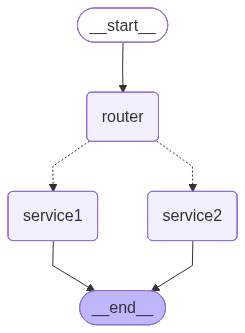

In [12]:
from IPython.display import Image, display
display(Image(multi_agent_graph.get_graph().draw_mermaid_png()))

In [18]:
# def run_multi_agent_stream(question: str, pdf_path: str = None, essay_path: str = None) -> str:
#     """
#     메인 그래프(multi_agent_graph)를 실행하고 최종 답변을 스트리밍 방식으로 추출합니다.
#     """
#     # 1. 초기 입력 설정 (메시지 + PDF 경로)
#     # MessagesState 구조에 맞춰 입력 구성
#     inputs = {
#         "messages": [("user", question)],
#         "user_pdf_path": pdf_path,
#         "essay_pdf_path": essay_path
#     }
    
#     final_answer = ""

#     # 2. multi_agent_graph 실행 (updates 모드)
#     for step in multi_agent_graph.stream(inputs, stream_mode="updates"):
#         for node_name, content in step.items():
#             # 디버깅용: 현재 실행 중인 노드 확인
#             print(f"--- [Node: {node_name}] 실행 중 ---")
            
#             # 노드 결과물에서 메시지 추출
#             if "messages" in content:
#                 last_msg = content["messages"][-1]
                
#                 # ✅ 튜플/객체 여부에 따른 안전한 텍스트 추출 (AttributeError 방지)
#                 if hasattr(last_msg, 'content'):
#                     # AIMessage 객체인 경우
#                     final_answer = last_msg.content
#                 elif isinstance(last_msg, (tuple, list)):
#                     # ('assistant', '내용') 튜플인 경우
#                     final_answer = last_msg[1]
#                 else:
#                     # 그 외 문자열인 경우
#                     final_answer = str(last_msg)

#     return final_answer

In [ ]:
# multiagent.py 파일 맨 아래에 추가

def run_multi_agent_stream(question: str, pdf_path: str = None, essay_path: str = None) -> str:
    """
    메인 그래프를 실행하고 최종 답변을 추출하여 반환합니다.
    """
    # MessagesState 구조에 맞춰 입력 구성
    inputs = {
        "messages": [("user", question)],
        "user_pdf_path": pdf_path,
        "essay_pdf_path": essay_path
    }

    final_answer = ""

    # multi_agent_graph가 이 파일 상단에 정의되어 있어야 합니다.
    for step in multi_agent_graph.stream(inputs, stream_mode="updates"):
        for node_name, content in step.items():
            # 터미널 디버깅용 로그
            print(f"--- [Node: {node_name}] 실행 중 ---")

            if "messages" in content:
                last_msg = content["messages"][-1]

                # 메시지 객체나 튜플에서 텍스트 추출
                if hasattr(last_msg, 'content'):
                    final_answer = last_msg.content
                elif isinstance(last_msg, (tuple, list)):
                    final_answer = last_msg[1]
                else:
                    final_answer = str(last_msg)

    return final_answer

In [19]:
# # 실제 실행 시나리오 테스트
# if __name__ == "__main__":
#     # 테스트 1: 학비 질문 (Service 1로 가야 함)
#     print("\n[테스트 1: 학비 질문]")
#     ans1 = run_multi_agent_stream("뉴욕대학교 학비 알려줘")
#     print(f"결과: {ans1}")

#     # 테스트 2: 인터뷰 연습 (Service 2로 가야 함)
#     print("\n[테스트 2: 인터뷰 연습]")
#     ans2 = run_multi_agent_stream(
#         "내 서류 바탕으로 비자 인터뷰 연습하고 싶어", 
#         pdf_path="workspace/3차프로젝트/f-1_yuji.pdf"
#     )
#     print(f"결과: {ans2}")

In [23]:
run_multi_agent_stream("UCLA대학교에 입학에 필요한 서류를 알려줘") 

--- [ROUTER DEBUG] 결정: service1 (LLM 답변: ADMISSIONS) ---
--- [FLOW DEBUG] service1 노드로 분기합니다 ---
--- [Node: router] 실행 중 ---
--- [Node: service1] 실행 중 ---


'UCLA 대학교 입학에 필요한 서류는 다음과 같습니다.\n\n*   **지원서:** Common Application 또는 Coalition Application을 통해 제출합니다.\n*   **고등학교 성적 증명서:** 정식 증명서 원본을 제출해야 합니다.\n*   **SAT/ACT 점수:** UCLA는 Test-Free 정책을 시행하고 있지만, 점수를 제출하는 것은 선택 사항입니다.\n*   **영어 능력 시험 점수:** TOEFL, IELTS 등 공인 영어 시험 점수가 필요합니다.\n*   **추천서:** 고등학교 교사 2명으로부터 추천서를 받아야 합니다.\n*   **에세이:** UCLA에서 요구하는 에세이를 작성해야 합니다.\n*   **경력 및 활동 내용:** 지원자의 경험과 활동을 보여주는 자료를 제출해야 합니다.\n\n자세한 내용은 UCLA 입학처 홈페이지에서 확인하실 수 있습니다.'

In [16]:
run_multi_agent_stream("비자 인터뷰 연습 시작할래", pdf_path="f-1_yuji.pdf")

--- [ROUTER DEBUG] 결정: service2 (LLM 답변: INTERVIEW) ---
--- [FLOW DEBUG] service2 노드로 분기합니다 ---
--- [Node: router] 실행 중 ---

[Service 2] f-1_yuji.pdf 파일을 기반으로 인터뷰를 생성합니다.
[PDF] Processing user_data: f-1_yuji.pdf
[PDF] Done — 1 doc(s) added to vector store.
[DATA] Loading HuggingFace QA dataset...


README.md:   0%|          | 0.00/417 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/98.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/335 [00:00<?, ? examples/s]

[DATA] 335 QA docs added.

Question 1 / 2

Officer: Okay, here's a question based on the provided information, adhering to all the rules:

"Could you please elaborate on your study plan and how your coursework in [지원자 전공] at [지원자 학교] will contribute to your career goals?"



엔터 누르고 말하세요 ▶  111


  [녹음 중... 8초]
--- [Node: service2] 실행 중 ---


'인터뷰 엔진 실행 중 오류가 발생했습니다: Error querying device -1'

In [ ]:
def get_next_question(profile_context, history):
    # history는 [{"question": "...", "answer": "..."}, ...] 리스트입니다.
    history_text = "".join(f"Q: {h['question']}\nA: {h['answer']}\n" for h in history)
    
    # 퀴즈 레퍼런스(q_ref)는 함수 내부에서 랜덤하게 뽑거나 인자로 받으세요
    # (기존에 작성하신 q_ref 로직 사용)
    
    question_prompt = f"""
    당신은 미국 F1 비자 면접관입니다. 
    지원자 정보: {profile_context}
    이전 대화: {history_text}
    [규칙] 영어로 간결한 질문 1개만 하세요.
    """
    return llm.invoke(question_prompt).content.strip()

def get_final_evaluation(profile_context, history):
    # 기존 final_prompt 로직 그대로 사용
    # ... (history_text와 audio_summary 조립) ...
    return llm.invoke(final_prompt).content.strip()